# DataGen Class Testing

This notebook is a small end-to-end smoke test for `DataGen`. It uses the simple ECM requested as `R-[P,R]-[P,R]`, labelled explicitly as `R1-[P2,R3]-[P4,R5]` so AutoEIS can map parameters unambiguously.

Run this notebook in the AutoREC environment. The setup cell searches from the current kernel working directory upward to find the `generate_data_pipline/` directory, so the notebook does not require a hard-coded launch directory.


## Example Command

Other users can run the same workflow from a shell with:

```bash
python - <<'PY'
from pathlib import Path
import sys

def find_pipeline_dir(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data_gen.py").exists() and (candidate / "ecm_simplification_functions").is_dir():
            return candidate
        nested = candidate / "generate_data_pipline"
        if (nested / "data_gen.py").exists() and (nested / "ecm_simplification_functions").is_dir():
            return nested
    raise FileNotFoundError("Could not find generate_data_pipline from the current working directory or its parents.")

pipeline_dir = find_pipeline_dir()
repo_dir = pipeline_dir.parent
for path in (repo_dir / "src", repo_dir):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from generate_data_pipline.data_gen import DataGen

generator = DataGen(
    random_ecm_circuit="R1-[P2,R3]-[P4,R5]",
    output_dir=pipeline_dir / "data" / "data_gen_class_testing",
    n_random_candidates=500,
    max_selected_curves=20,
    excluded_simplified_ecms=("R1", "R1-C2"),
    verbose=True,
)

balanced_df, batch_infos = generator.generate_data(
    target_per_relabel=1,
    min_batches=1,
    max_batches=5,
    seed_start=2026,
    n_random_candidates=500,
    max_selected_curves=20,
    export=True,
    export_plots=True,
    export_dataprep=True,
)
print(balanced_df[["original_ecm", "relabel_ecm"]].head())
print(batch_infos)
PY
```


In [1]:
from pathlib import Path
import sys

def find_pipeline_dir(start=Path.cwd()):
    """Find the generate_data_pipline directory containing data_gen.py."""
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data_gen.py").exists() and (candidate / "ecm_simplification_functions").is_dir():
            return candidate
        nested = candidate / "generate_data_pipline"
        if (nested / "data_gen.py").exists() and (nested / "ecm_simplification_functions").is_dir():
            return nested
    raise FileNotFoundError(
        "Could not find generate_data_pipline from the current working "
        "directory or its parents. If your kernel starts elsewhere, set "
        "pipeline_dir manually to the directory containing data_gen.py."
    )

pipeline_dir = find_pipeline_dir()
repo_dir = pipeline_dir.parent
for path in (repo_dir / "src", repo_dir):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

try:
    import autoeis  # noqa: F401
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from tqdm.auto import tqdm  # noqa: F401
except ImportError as exc:
    raise ImportError("Run this notebook in the AutoREC environment.") from exc

from generate_data_pipline.data_gen import DataGen

%matplotlib inline

I0000 00:00:1783433489.988994   51766 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783433491.299887   51766 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
source_ecm = "R1-[P2,R3]-[P4,R5]"
output_dir = pipeline_dir / "data" / "data_gen_class_testing"

generator = DataGen(
    random_ecm_circuit=source_ecm,
    output_dir=output_dir,
    n_random_candidates=500,
    max_selected_curves=20,
    excluded_simplified_ecms=("R1", "R1-C2"),
    fim_refit_max_iters=3,
    fim_refit_min_iters=1,
    fim_refit_max_nfev=100,
    verbose=True,
)

source_ecm


'R1-[P2,R3]-[P4,R5]'

## Generate a Small Dataset

`target_per_relabel=1` keeps this notebook fast while still exercising sampling, filtering, selection, simplify/FIM relabelling, postprocessing, balancing, and CSV export.

In [3]:
balanced_df, batch_infos = generator.generate_data(
    target_per_relabel=1,
    min_batches=1,
    max_batches=5,
    seed_start=2026,
    n_random_candidates=500,
    max_selected_curves=20,
    export=False,
)

final_df, export_df, csv_path = generator.export_table_csv(
    balanced_df,
    target_per_relabel=1,
)
dataprep_dir = generator.export_dataprep_folder(final_df)
first_eis_csv = sorted(dataprep_dir.rglob("eis_*.csv"))[0]

print(f"CSV saved to: {csv_path}")
print(f"EISDataPrep folder saved to: {dataprep_dir}")
print(f"Example EIS CSV: {first_eis_csv}")
print(f"Generated rows: {len(final_df)}")
display(final_df[["global_position", "original_ecm", "simplified_ecm", "fim_relabel_ecm", "relabel_ecm"]])
display(export_df.head())
display(pd.read_csv(first_eis_csv).head())

Simulating random candidates:   0%|          | 0/500 [00:00<?, ?it/s]

Parser full simplify selected curves:   0%|          | 0/20 [00:00<?, ?it/s]

Dropping 0 excluded simplified ECMs
Keeping 20 rows after simplified ECM exclusion
Dropping 0 final relabelled ECMs with P-P series
Keeping 20 final relabelled ECMs
Dropping 0 invalid relabelled ECMs
Keeping 20 valid relabelled ECMs
Batch 1: first-batch target groups 3, discovered groups 3
Added this batch:
R1-[P1,R2]            1
R1-[P1,R2]-P2         1
R1-[P1,R2]-[P2,R3]    1
Accumulated target counts:
R1-[P1,R2]            1
R1-[P1,R2]-P2         1
R1-[P1,R2]-[P2,R3]    1
Generated relabel counts before final export trimming:
relabel_ecm
R1-[P1,R2]            1
R1-[P1,R2]-P2         1
R1-[P1,R2]-[P2,R3]    1
Generated rows: 3
Dropping 0 excluded simplified ECMs
Keeping 3 rows after simplified ECM exclusion
CSV saved to: /mnt/d/utoronto_research/myprojects/rl_data_generation/AutoREC/generate_data_pipline/data/data_gen_class_testing/balanced_final_params_R1-[P2,R3]-[P4,R5]_cfde792e.csv
EISDataPrep folder saved to: /mnt/d/utoronto_research/myprojects/rl_data_generation/AutoREC/generate

,global_position,original_ecm,simplified_ecm,fim_relabel_ecm,relabel_ecm
0,0,"R1-[P2,R3]-[P4,R5]","R1-[C2,R3]","R1-[C2,R3]","R1-[P1,R2]"
1,1,"R1-[P2,R3]-[P4,R5]","R1-[P2,R3]-C4","R1-[P2,R3]-C4","R1-[P1,R2]-P2"
2,2,"R1-[P2,R3]-[P4,R5]","R1-[P2,R3]-[P4,R5]","R1-[P2,R3]-[P4,R5]","R1-[P1,R2]-[P2,R3]"


,original_ecm,original_params_json,final_simplified_ecm,final_simplified_params_json,frequency_hz_json,impedance_data_json
0,"R1-[P2,R3]-[P4,R5]","{""P2n"": 0.7790242157763081, ""P2w"": 2.976642868...","R1-[P1,R2]","{""P1n"": 1.0, ""P1w"": 2.295100764595544e-07, ""R1...","[100000.0, 81544.07395185171, 66494.3599666504...","{""real_ohm"": [12.114369922486922, 12.133116341..."
1,"R1-[P2,R3]-[P4,R5]","{""P2n"": 0.5957109798278332, ""P2w"": 0.000164635...","R1-[P1,R2]-P2","{""P1n"": 0.587736140547976, ""P1w"": 0.0001796821...","[100000.0, 81544.07395185171, 66494.3599666504...","{""real_ohm"": [1.2861377787304635, 1.4523608563..."
2,"R1-[P2,R3]-[P4,R5]","{""P2n"": 0.7688571166733182, ""P2w"": 2.609410792...","R1-[P1,R2]-[P2,R3]","{""P1n"": 0.7688571166733182, ""P1w"": 2.609410792...","[100000.0, 81544.07395185171, 66494.3599666504...","{""real_ohm"": [50.16807096084232, 59.2072209614..."


,freq,Z_real,Z_imag
0,0.010000,2205.214804,-0.070126
1,0.012263,2205.214803,-0.085998
2,0.015039,2205.214801,-0.105462
3,0.018443,2205.214799,-0.129331
4,0.022617,2205.214795,-0.158602


## Plot Generated EIS Data

The final ECM label is used as the plot title.

Plot saved to: /mnt/d/utoronto_research/myprojects/rl_data_generation/AutoREC/generate_data_pipline/data/data_gen_class_testing/data_gen_class_testing_example.png


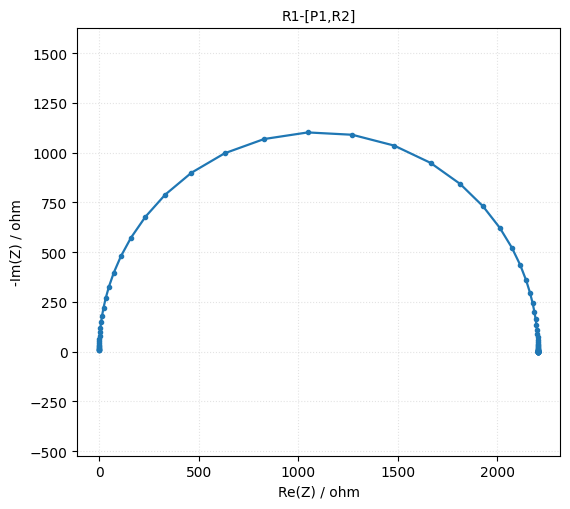

In [4]:
row = final_df.iloc[0]
Z = np.asarray(generator.simulate_relabel_impedance(row, generator.random_ecm_freq))
title = str(row["relabel_ecm"])

fig, ax = plt.subplots(figsize=(5.8, 5.2))
ax.plot(np.real(Z), -np.imag(Z), marker="o", markersize=3, linewidth=1.6)
ax.set_title(title, fontsize=10, wrap=True)
ax.set_xlabel("Re(Z) / ohm")
ax.set_ylabel("-Im(Z) / ohm")
ax.grid(True, linestyle=":", alpha=0.35)
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()

plot_path = output_dir / "data_gen_class_testing_example.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
print(f"Plot saved to: {plot_path}")
plt.show()

## Batch Metadata

In [5]:
pd.DataFrame(batch_infos)

,batch_id,seed,valid_candidate_count,filtered_candidate_count,selected_curve_count,after_final_filters_count,removed_by_high_frequency_filter,removed_by_excluded_simplified_ecm_filter
0,0,2026,500,317,20,20,183,0


## Larger Batch Export

This optional cell generates a larger balanced set and exports it in the EISDataPrep-compatible folder structure. Each final ECM gets its own folder, and each EIS curve is written as `eis_N.csv` with `freq`, `Z_real`, and `Z_imag` columns.

In [6]:
batch_generator = DataGen(
    random_ecm_circuit=source_ecm,
    output_dir=pipeline_dir / "data" / "data_gen_batch",
    n_random_candidates=500,
    max_selected_curves=20,
    excluded_simplified_ecms=("R1", "R1-C2"),
    fim_refit_max_iters=10,
    fim_refit_min_iters=1,
    fim_refit_max_nfev=100,
    verbose=True,
)

batch_balanced_df, batch_infos = batch_generator.generate_data(
    target_per_relabel=100,
    min_batches=1,
    max_batches=100,
    seed_start=2026,
    n_random_candidates=5000,
    max_selected_curves=150,
    export=False,
)

batch_final_df = batch_generator.build_final_relabel_df(
    batch_balanced_df,
    target_per_relabel=100,
)
batch_dataprep_dir = batch_generator.export_dataprep_folder(
    batch_final_df,
    output_dir=pipeline_dir / "data" / "data_gen_batch_eisdataprep",
)

batch_files = sorted(batch_dataprep_dir.rglob("eis_*.csv"))
print(f"EISDataPrep folder saved to: {batch_dataprep_dir}")
print(f"CSV files written: {len(batch_files)}")
display(pd.DataFrame(batch_infos))
display(pd.read_csv(batch_files[0]).head())


Simulating random candidates:   0%|          | 0/5000 [00:00<?, ?it/s]

Parser full simplify selected curves:   0%|          | 0/150 [00:00<?, ?it/s]

Dropping 0 excluded simplified ECMs
Keeping 150 rows after simplified ECM exclusion
Dropping 0 final relabelled ECMs with P-P series
Keeping 150 final relabelled ECMs
Dropping 1 invalid relabelled ECMs
Keeping 149 valid relabelled ECMs
Batch 1: first-batch target groups 3, discovered groups 3
Added this batch:
R1-[P1,R2]             17
R1-[P1,R2]-P2          22
R1-[P1,R2]-[P2,R3]    100
Accumulated target counts:
R1-[P1,R2]             17
R1-[P1,R2]-P2          22
R1-[P1,R2]-[P2,R3]    100


Simulating random candidates:   0%|          | 0/5000 [00:00<?, ?it/s]

Parser full simplify selected curves:   0%|          | 0/150 [00:00<?, ?it/s]

...

Simulating random candidates:   0%|          | 0/5000 [00:00<?, ?it/s]

Parser full simplify selected curves:   0%|          | 0/150 [00:00<?, ?it/s]

Dropping 0 excluded simplified ECMs
Keeping 150 rows after simplified ECM exclusion
Dropping 0 final relabelled ECMs with P-P series
Keeping 150 final relabelled ECMs
Dropping 1 invalid relabelled ECMs
Keeping 149 valid relabelled ECMs
Batch 8: first-batch target groups 3, discovered groups 3
Added this batch:
R1-[P1,R2]            12
R1-[P1,R2]-P2          0
R1-[P1,R2]-[P2,R3]     0
Accumulated target counts:
R1-[P1,R2]            100
R1-[P1,R2]-P2         100
R1-[P1,R2]-[P2,R3]    100
Generated relabel counts before final export trimming:
relabel_ecm
R1-[P1,R2]            100
R1-[P1,R2]-P2         100
R1-[P1,R2]-[P2,R3]    100
Generated rows: 300
Dropping 0 excluded simplified ECMs
Keeping 300 rows after simplified ECM exclusion
EISDataPrep folder saved to: /mnt/d/utoronto_research/myprojects/rl_data_generation/AutoREC/generate_data_pipline/data/data_gen_batch_eisdataprep
CSV files written: 300


,batch_id,seed,valid_candidate_count,filtered_candidate_count,selected_curve_count,after_final_filters_count,removed_by_high_frequency_filter,removed_by_excluded_simplified_ecm_filter
0,0,2026,5000,3015,150,149,1985,0
1,1,2027,5000,2994,150,150,2006,0
2,2,2028,5000,3008,150,149,1992,0
3,3,2029,5000,3009,150,149,1991,0
4,4,2030,5000,3012,150,149,1988,0
5,5,2031,5000,2993,150,148,2007,0
6,6,2032,5000,3031,150,148,1969,0
7,7,2033,5000,3023,150,149,1977,0


,freq,Z_real,Z_imag
0,0.010000,27480.944681,-257.885299
1,0.012263,27451.872240,-283.072400
2,0.015039,27419.909982,-310.654458
3,0.018443,27384.772886,-340.845643
4,0.022617,27346.148372,-373.876421


In [7]:
plot_dir = pipeline_dir / "data" / "plots"
plot_dir.mkdir(exist_ok=True, parents=True)
for ii, row in batch_final_df.iterrows():
    Z = row.Z
    plt.figure()
    plt.title(row.relabel_ecm)
    plt.plot(Z.real, -Z.imag)
    plt.xlabel("Re(Z)")
    plt.ylabel("-Im(Z)")
    plt.savefig(plot_dir / f"eis_{ii}.png")
    plt.close()

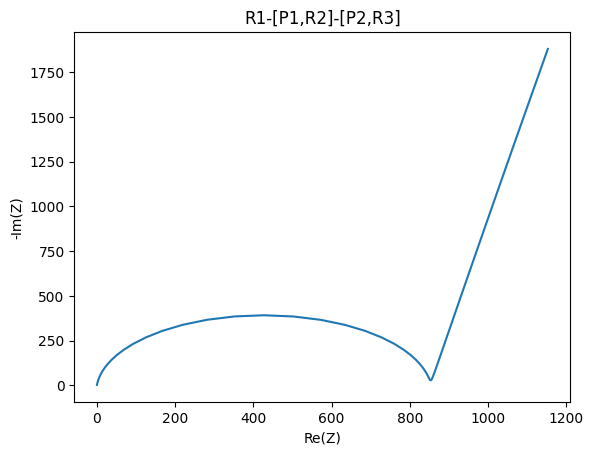

Iteration 1:
Current circuit: R1-[P2,R3]-[P4,R5]
Current parameters: {'R1': 0.01, 'P2w': 0.006353711610290957, 'P2n': 0.9011826818032258, 'R3': 599102.3670950191, 'P4w': 1.5188061867686913e-06, 'P4n': 0.9461271978595516, 'R5': 852.0030151249123}
Simplified circuit after combining series and parallel components: R1-[C2,R3]-[C4,R5]
Corresponding parameters:
{'R1': 0.01,
 'C2': 0.006353711610290957,
 'R3': 599102.3670950191,
 'C4': 1.5188061867686913e-06,
 'R5': 852.0030151249123}
Dropping unidentifiable components...
Circuit: R1-[C2,R3]-[C4,R5]
Original parameters:
{'R1': 0.01,
 'C2': 0.006353711610290957,
 'R3': 599102.3670950191,
 'C4': 1.5188061867686913e-06,
 'R5': 852.0030151249123}
Eigenvalues of FIM (normalized): [2.13797104e-06 2.04677453e-01 2.86890196e-01 6.14719949e-01
 1.00000000e+00]
FIM rank: 5 (# parameters:  5)
No unidentifiable parameters suggested to drop.
Simplified circuit after removing unidentifiable components: R1-[P2,R3]-[P4,R5]
Corresponding parameters:
{'R1': 0.

('R1-[P2,R3]-[P4,R5]',
 {'R1': 0.01,
  'P2w': 0.006353711610290957,
  'P2n': 0.9011826818032258,
  'R3': 599102.3670950191,
  'P4w': 1.5188061867686913e-06,
  'P4n': 0.9461271978595516,
  'R5': 852.0030151249123})

In [8]:
eis_i = 263
circuit = batch_final_df.loc[eis_i, "relabel_ecm"]
Z = batch_final_df.loc[eis_i, "Z"]

plt.figure()
plt.title(circuit)
plt.plot(Z.real, -Z.imag)
plt.xlabel("Re(Z)")
plt.ylabel("-Im(Z)")
plt.show()
plt.close()

generator.run_parser_full_simplify(
    batch_final_df.original_ecm[eis_i], batch_final_df.params[eis_i], Z, True
)

# UMAP analysis

In [9]:
# from autorec.data_preparation import EISDataPrep
# import umap
# import seaborn as sns

In [10]:
# data_prep_training = EISDataPrep("../data/examples/training_dataset.pkl", mode="load")
# data_training = data_prep_training.load()

In [11]:
# data_prep_new = EISDataPrep(
#     path=pipeline_dir / "data" / "data_gen_batch_eisdataprep",
#     mode="process",
#     evaluation=True,
# )
# data_new = data_prep_new.load()
# data_new.to_pickle(pipeline_dir / "data" / "data_gen_batch_eisdataprep.pkl")
# print(data_prep_new.get_summary())

In [12]:
# flatten_Z_training = np.vstack(data_training.flatten_Z.values)
# flatten_Z_new = np.vstack(data_new.flatten_Z.values)
# reducer = umap.UMAP(random_state=42, transform_seed=42)
# reducer.fit(flatten_Z_training)

In [13]:
# embedding_training = reducer.transform(flatten_Z_training)
# embedding_new = reducer.transform(flatten_Z_new)

In [14]:
# plot_df_training = pd.DataFrame({
#     "UMAP 1": embedding_training[:, 0],
#     "UMAP 2": embedding_training[:, 1],
#     "ecm": data_training.true_circuit
# })
# plot_df_new = pd.DataFrame({
#     "UMAP 1": embedding_new[:, 0],
#     "UMAP 2": embedding_new[:, 1],
#     "ecm": data_new.true_circuit
# })

In [15]:
# plt.figure()
# sns.scatterplot(
#     data=plot_df_training, x="UMAP 1", y="UMAP 2", hue="ecm", s=25, alpha=0.8
# )
# sns.scatterplot(
#     data=plot_df_new,
#     x="UMAP 1",
#     y="UMAP 2",
#     hue="ecm",
#     marker="D",
#     edgecolor="black",
#     linewidth=1,
#     s=25,
#     alpha=0.8,
# )
# plt.legend(title="ECM", bbox_to_anchor=(1, 1))
# # plt.tight_layout()
# plt.show()